In [5]:
import numpy as np
from os import listdir

from AutoencoderAPI.utils.decibels import file_name_table
from AutoencoderAPI.utils.correlation import second_order
from AutoencoderAPI.autoencoderKernelDensity import autoencoder_kernelDensity

In [6]:
decibel_dict= file_name_table('Datasets/NIST (250) test/', 250, (67,71))

In [7]:
signal_size = 800
path_test = 'Datasets/NIST (800)/'
path_train = 'Datasets/NIST (250) train/'

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

#X = np.concatenate((X_test,X_train))

{'files': {'dataset': 'Datasets/NIST (250) train', 'path_save': 'AutoencoderLog/', 'input_dimension': 250}, 'network': {'network_type': 'generic', 'activation_list': ['Mish', 'CELU', 'Tanh', 'CELU', 'Mish'], 'layer_list': [250, 50, 25, 1, 25, 50, 250], 'layer_type': 'Linear', 'bw_cst': [0.01]}, 'train': {'optimizer': 'Adam', 'criterion': 'TripletMSE', 'alpha': 0.002, 'epochs': 10, 'skip_elements': 1, 'learning_rate': 1e-06}}


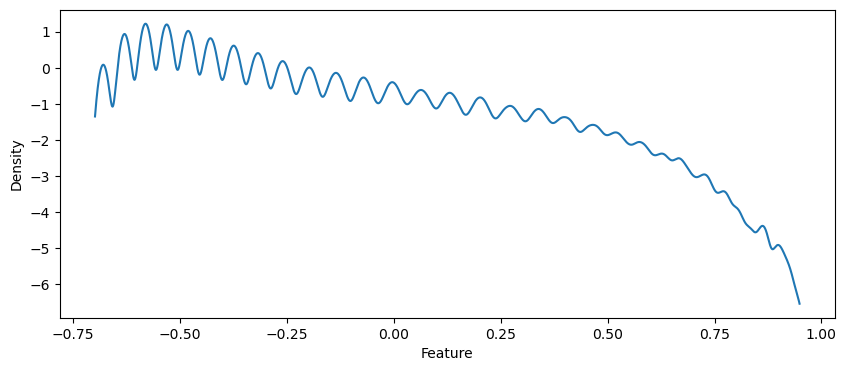

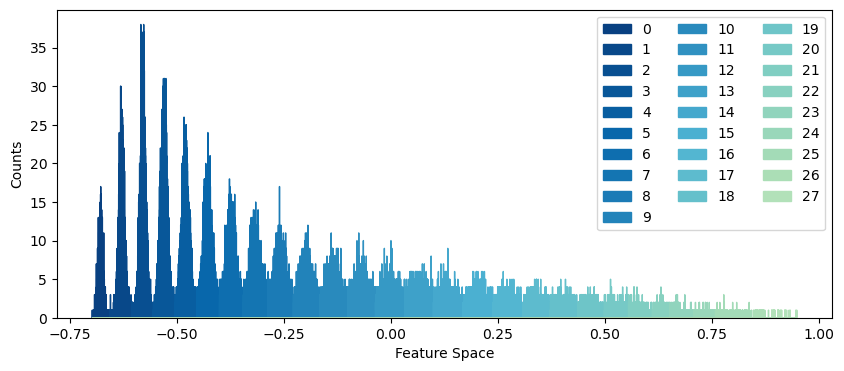

In [8]:
ak = autoencoder_kernelDensity("AutoencoderLog/run-2023-10-04-13-04/fold 1")
ak.fit(X[::10], plot_cluster=True, plot_traces=False, plot_density=True, bw_cst=[0.01], flip=True)

In [9]:
decibel = []
g2 = []
average = []
labels = []
for key in decibel_dict.keys():
    X = decibel_dict[key]
    labels_ = ak.get_label(X)
    labels = np.concatenate([labels, labels_])
    decibel.append(float(key))
    g2.append(second_order(labels_))
    average.append(np.mean(labels_))

In [10]:
decibel

[26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0]

In [11]:
g2

[0.9980347668631419,
 0.9992054034101929,
 1.0012174359988195,
 0.9989379782230778,
 0.9959163135655122,
 1.0122171713840997,
 0.9998507912946792]

In [12]:
average

[15.88349609375,
 11.284375,
 8.00068359375,
 5.65126953125,
 4.0357421875,
 2.85634765625,
 2.00361328125]

In [21]:
def function(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * 10**(-dB * cst)

def function1(dB, n_0, cst):
    dB = np.array(dB)
    return n_0 * np.exp(-dB - cst)

[9.11151742e+08 2.98400889e-01]


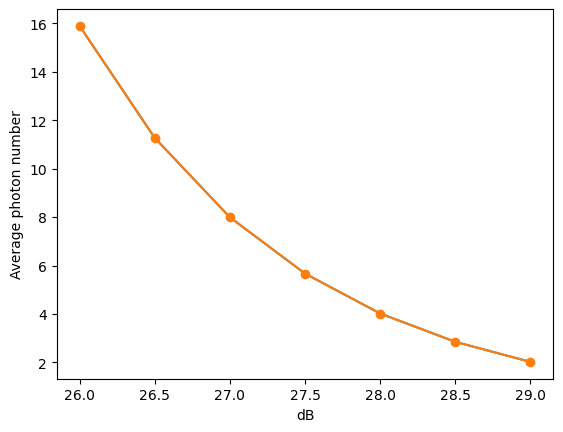

In [22]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

popt, pcov = curve_fit(function, decibel, average, 
                       bounds=([0, 0], [1e9, 40]),
                       p0=[4,0.1])
plt.plot(decibel, function(decibel, *popt))
plt.plot(decibel, average,marker='o' )
#plt.yscale("log")
plt.xlabel("dB")
plt.ylabel("Average photon number")
print(popt)

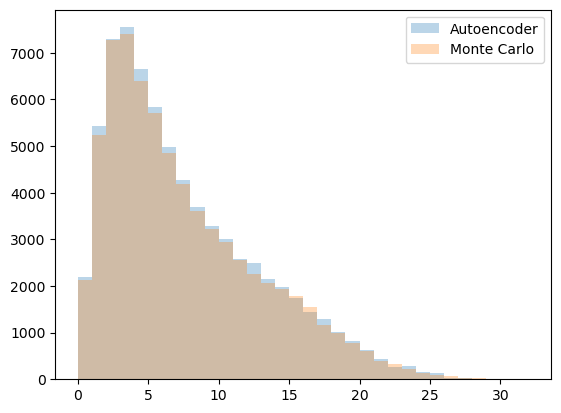

In [23]:
import numpy.random as npr

decibel = np.arange(26,29.5,0.5)
average = function(decibel, *popt)
n = np.concatenate([npr.poisson(i, 10_000) for i in average])
n_pos = np.unique(n)
plt.hist(labels, alpha=0.3, bins=n_pos, label='Autoencoder')
plt.hist(n, alpha=0.3, bins=n_pos, label='Monte Carlo')
plt.legend()
plt.show()